# INF-8239 · U03 · Ejercicio 06 — Autoencoder y VAE con Fashion-MNIST

Notebook ejecutado que consolida la evidencia del laboratorio U03.LAB10. **No calcula nada por su cuenta**: ejecuta `scripts/train_ae_vae.py` (la misma fuente que se usa desde la terminal), que entrena los modelos y genera todos los artefactos en `reports/` y `models/`. El notebook solo los presenta e interpreta.

Ejecución reproducible desde la raíz del proyecto:

```bash
uv run --with jupyter jupyter nbconvert --to notebook --execute --inplace notebooks/ae_vae_fashion_mnist.ipynb
```

## 1. Entorno

In [1]:
import importlib
import json
import platform
import sys
from pathlib import Path

import tensorflow as tf
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
REPORTS = ROOT / "reports"
sys.path.insert(0, str(ROOT / "scripts"))
import train_ae_vae

train_ae_vae = importlib.reload(train_ae_vae)  # usa siempre la versión actual del script

print("Python:", platform.python_version(), "|", platform.platform())
print("TensorFlow:", tf.__version__, "| Keras:", tf.keras.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "ninguna (CPU)")

Python: 3.12.14 | Windows-11-10.0.26300-SP0
TensorFlow: 2.21.0 | Keras: 3.15.1


GPU: ninguna (CPU)


## 2. Entrenamiento y generación de artefactos

Se ejecuta el script con los parámetros del manual (`--epochs-ae 6 --epochs-vae 8`, semilla 42). Regenera todo `reports/` y `models/`.

In [2]:
train_ae_vae.main(["--epochs-ae", "6", "--epochs-vae", "8"])
metrics = json.loads((REPORTS / "training_metrics.json").read_text(encoding="utf-8"))
print("\nArtefactos generados:", sorted(path.name for path in REPORTS.glob("*.*") if path.name != ".gitkeep"))

Epoch 1/6


211/211 - 1s - 6ms/step - loss: 0.4499 - val_loss: 0.3737


Epoch 2/6


211/211 - 1s - 3ms/step - loss: 0.3502 - val_loss: 0.3386


Epoch 3/6


...

Epoch 7/8


235/235 - 1s - 4ms/step - kl: 6.2162 - loss: 274.9633 - reconstruction: 268.7472


Epoch 8/8


235/235 - 1s - 4ms/step - kl: 6.2620 - loss: 273.6118 - reconstruction: 267.3499


{
  "ae_train_seconds": 4.597972899999149,
  "vae_train_seconds": 9.523611399999936,
  "ae_best_val_loss": 0.3071039319038391,
  "test_fidelity": {
    "autoencoder": {
      "bce": 0.3068279027938843,
      "mse": 0.02029494196176529
    },
    "vae": {
      "bce": 0.34105178713798523,
      "mse": 0.03320646286010742
    }
  },
  "diversity": {
    "generated_mean_pairwise": 5.958987712860107,
    "real_mean_pairwise": 11.262284278869629,
    "ratio": 0.5291100424485288
  }
}

Artefactos generados: ['ae_vae_panel.png', 'interpolation.png', 'latent_space.png', 'loss_curves.png', 'nearest_neighbors.png', 'per_class_mse.png', 'results_table.md', 'training_metrics.json']


## 3. Dataset y particiones

Fashion-MNIST (Zalando, licencia MIT): 28×28 en escala de grises, 10 clases balanceadas. Se descarga con Keras y no se redistribuye. El AE separa el 10 % del entrenamiento para validación; el conjunto de prueba se reserva para la evaluación final.

In [3]:
partitions = metrics["partitions"]
train_ae = int(partitions["train"] * (1 - partitions["ae_validation_fraction"]))
print(f"Entrenamiento: {partitions['train']:,} (AE: {train_ae:,} entrenamiento + {partitions['train'] - train_ae:,} validación)")
print(f"Prueba: {partitions['test']:,}")

Entrenamiento: 60,000 (AE: 54,000 entrenamiento + 6,000 validación)
Prueba: 10,000


## 4. Curvas de pérdida

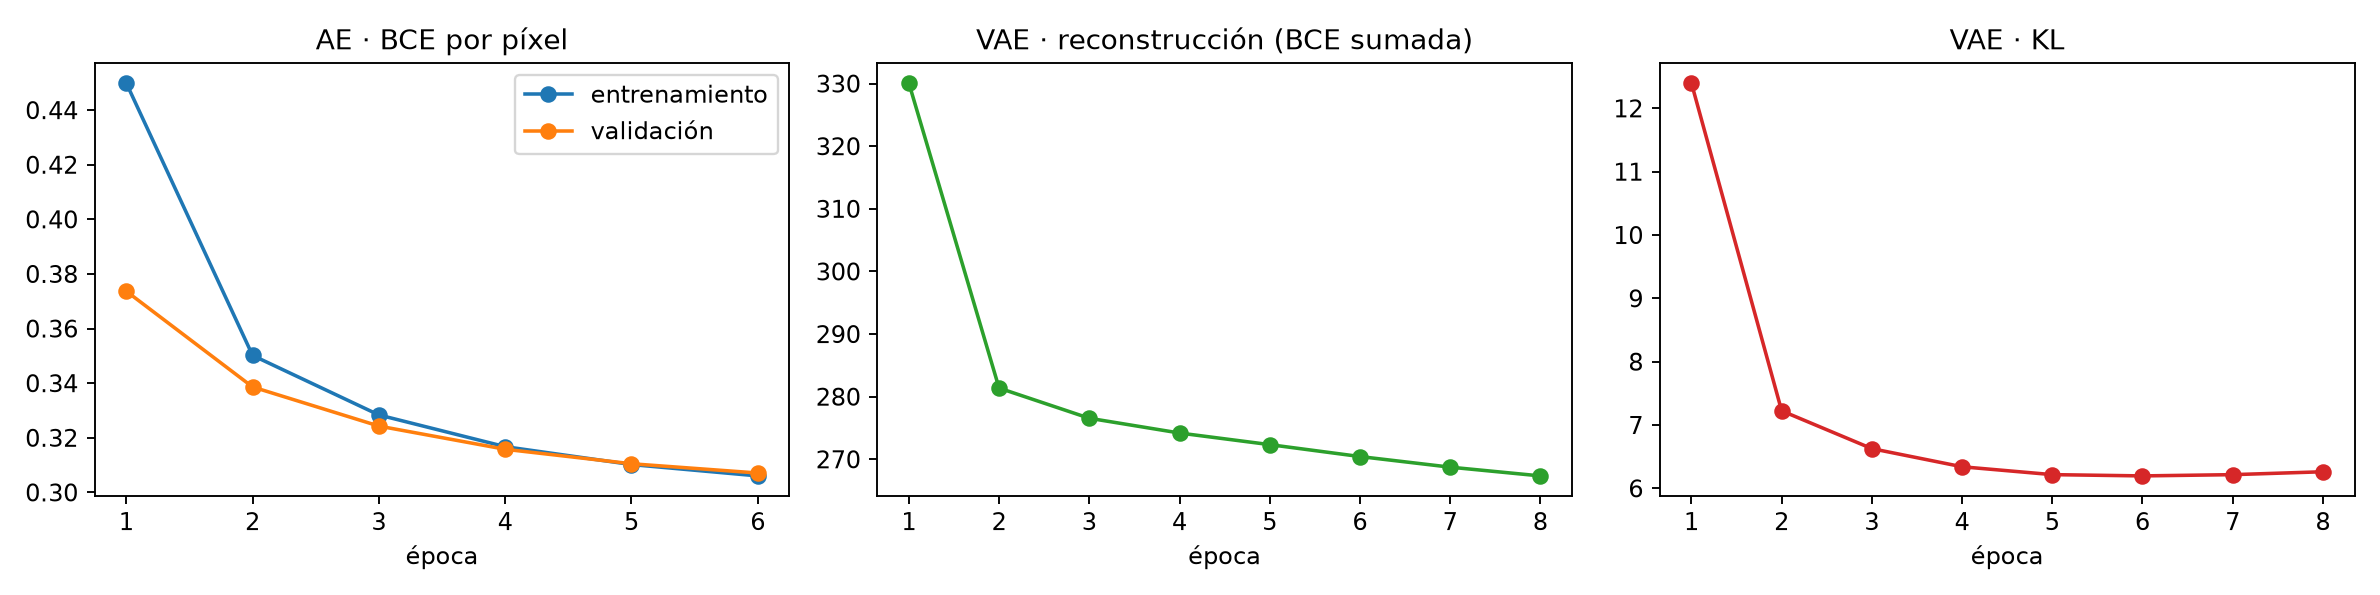

AE: mejor val_loss = 0.3071 en la época 6
VAE: reconstrucción final = 267.35 | KL final = 6.26


In [4]:
display(Image(filename=str(REPORTS / "loss_curves.png")))
print(f"AE: mejor val_loss = {metrics['ae_best_val_loss']:.4f} en la época {metrics['ae_best_epoch']}")
print(f"VAE: reconstrucción final = {metrics['vae_final_reconstruction']:.2f} | KL final = {metrics['vae_final_kl']:.2f}")

**Lectura.** Las pérdidas de entrenamiento y validación del AE descienden juntas: no hay sobreajuste y el mejor punto es la última época, lo que sugiere margen con más épocas. En el VAE la KL cae rápido y se estabiliza en torno a 6.2 (sin colapso del latente), mientras la reconstrucción sigue bajando. El VAE se entrena sin validación, por lo que sus curvas son solo de entrenamiento.

## 5. Fidelidad sobre el conjunto de prueba

Métricas **por píxel** sobre las 10,000 imágenes de prueba, para que el AE y el VAE sean comparables. El VAE reconstruye desde la media del posterior (`z_mean`).

AE (latente 16D)   BCE/píxel 0.3068 | MSE/píxel 0.0203
VAE (latente 2D)   BCE/píxel 0.3411 | MSE/píxel 0.0332
KL media por dimensión latente (prueba): [3.003200054168701, 3.3238000869750977]


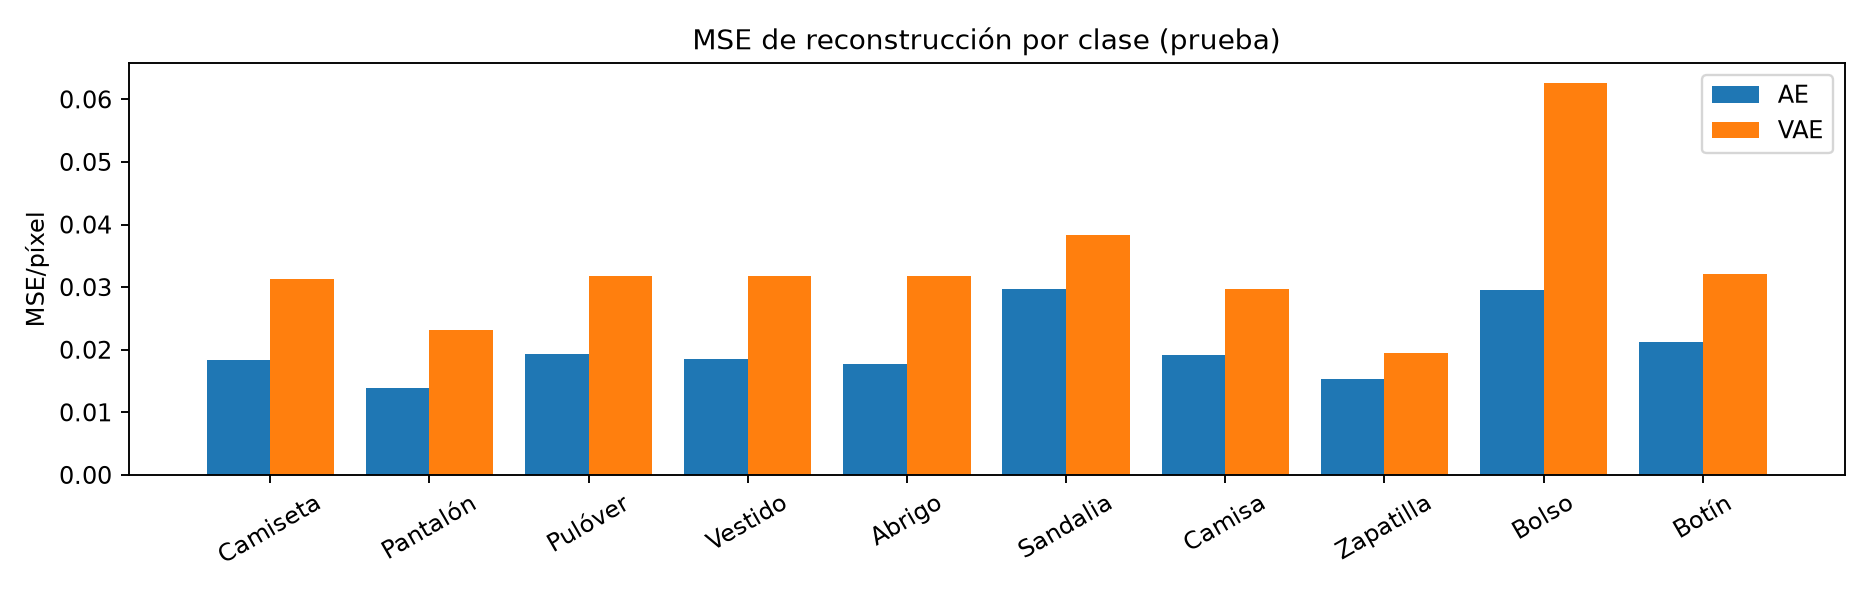

In [5]:
for name, label in [("autoencoder", "AE (latente 16D)"), ("vae", "VAE (latente 2D)")]:
    values = metrics["test_fidelity"][name]
    print(f"{label:<18} BCE/píxel {values['bce']:.4f} | MSE/píxel {values['mse']:.4f}")
print("KL media por dimensión latente (prueba):", metrics["vae_test_kl_per_dimension"])
display(Image(filename=str(REPORTS / "per_class_mse.png")))

**Lectura.** En prueba, el AE (BCE 0.3068, MSE 0.0203 por píxel) reconstruye mejor que el VAE (BCE 0.3411, MSE 0.0332), coherente con un latente 8 veces mayor y sin regularización KL. La BCE de prueba del AE es prácticamente igual a su val_loss (0.3071), lo que confirma que generaliza sin sobreajuste. Por clase, el **bolso** es el mayor fallo del VAE (MSE ≈0.062, el doble que el resto) y la **sandalia** el del AE: estructuras finas y formas poco regulares que el cuello de botella no conserva. La KL de prueba se reparte entre las dos dimensiones (≈3.0 y ≈3.3), así que ambas se usan y no hay colapso. Las cifras de AE y VAE se comparan con cautela: difieren en dimensión latente y arquitectura.

## 6. Reconstrucción, muestreo e interpolación (paneles no seleccionados)

16 ejemplos de prueba elegidos con semilla 42. Filas: original, reconstrucción AE, reconstrucción VAE y muestra nueva desde N(0, I).

Ejemplos del panel: ['Camiseta', 'Sandalia', 'Pantalón', 'Vestido', 'Abrigo', 'Sandalia', 'Bolso', 'Botín', 'Zapatilla', 'Sandalia', 'Pulóver', 'Botín', 'Zapatilla', 'Botín', 'Bolso', 'Bolso']


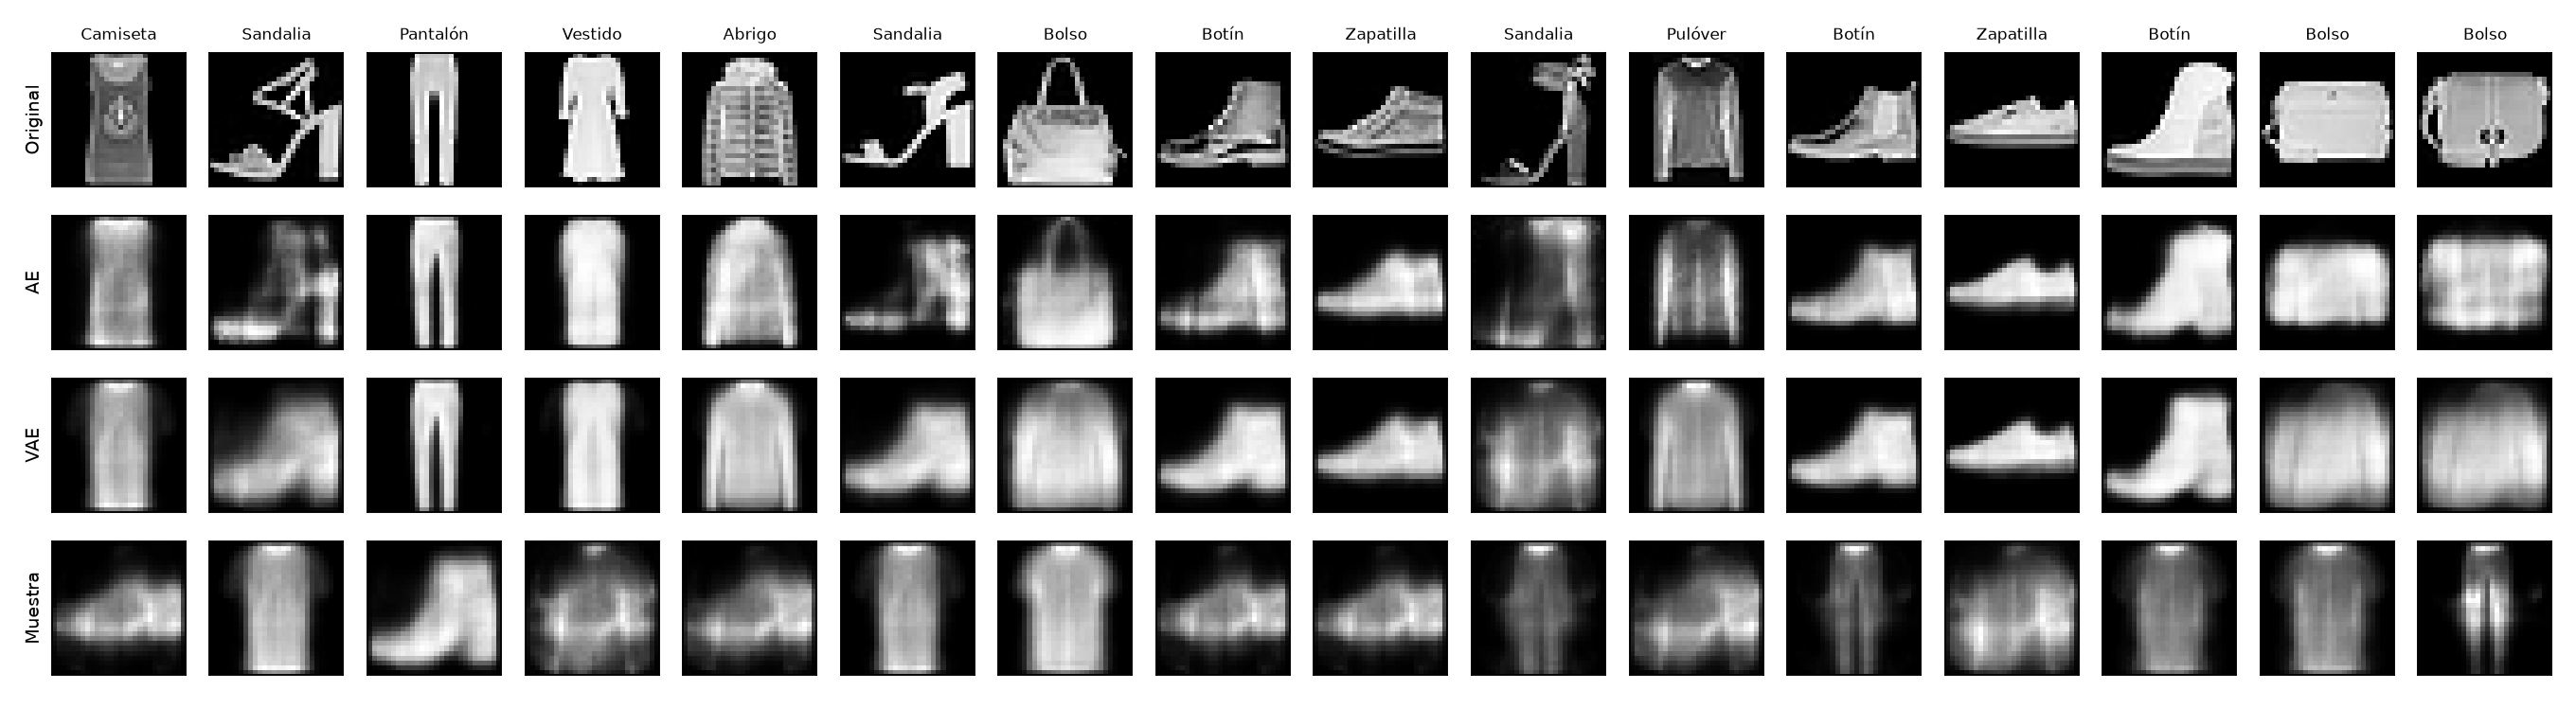

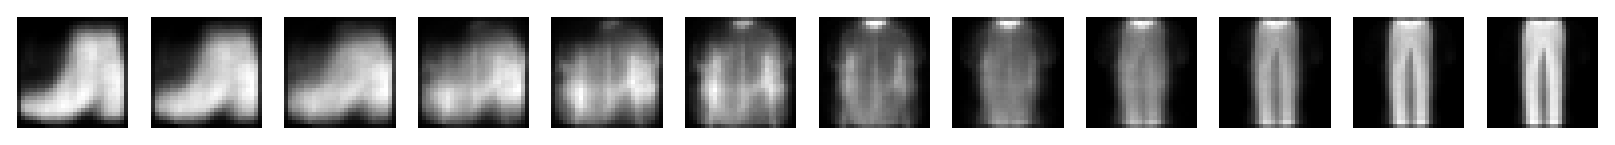

In [6]:
print("Ejemplos del panel:", metrics["panel_test_classes"])
display(Image(filename=str(REPORTS / "ae_vae_panel.png")))
display(Image(filename=str(REPORTS / "interpolation.png")))

## 7. Espacio latente del VAE

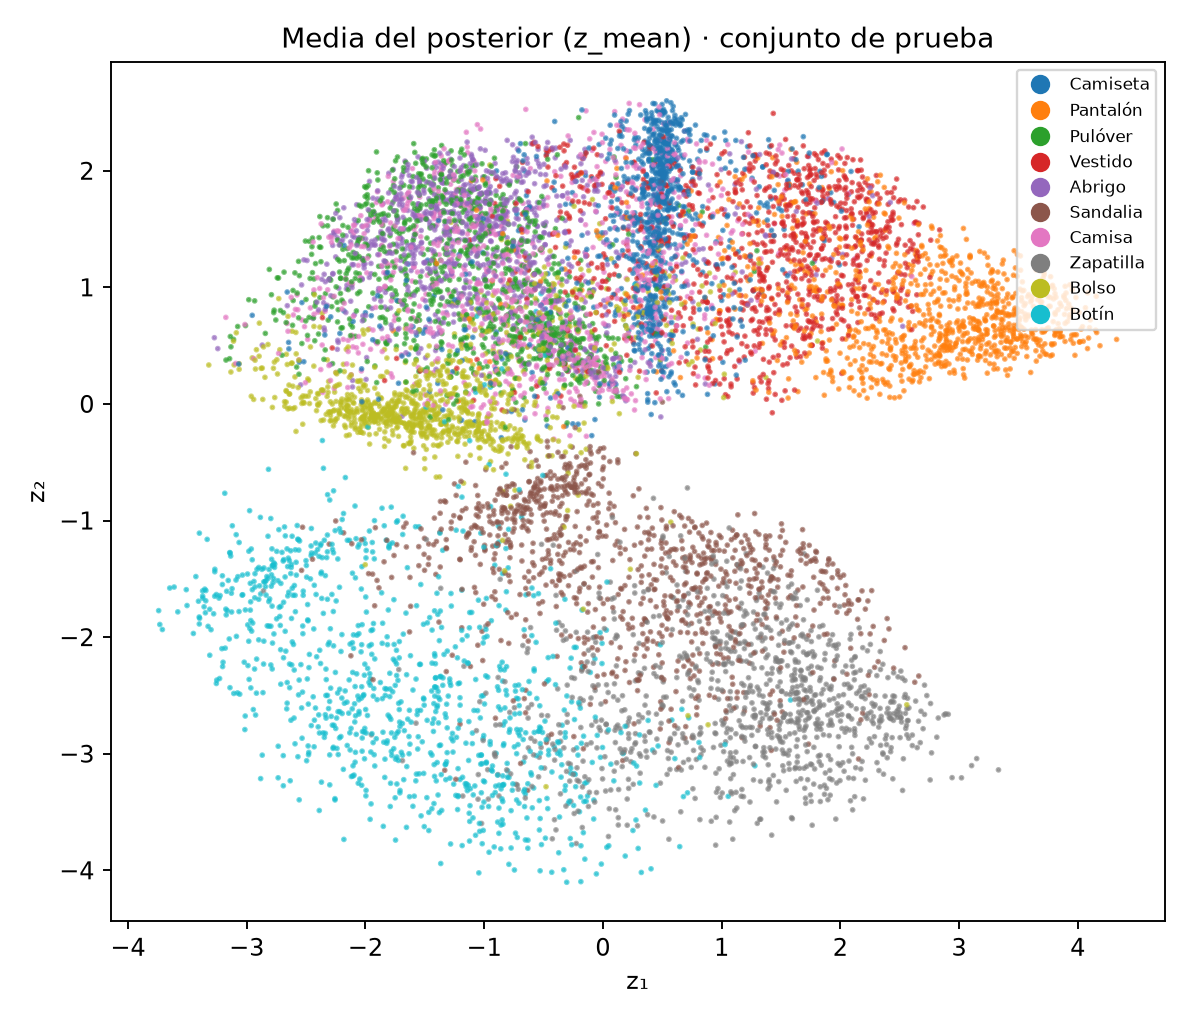

In [7]:
display(Image(filename=str(REPORTS / "latent_space.png")))

**Lectura.** El latente 2D separa con claridad el **calzado** (mitad inferior: botín, sandalia y zapatilla, con la sandalia entre las otras dos) de la **ropa** (mitad superior), y el bolso queda en una franja intermedia. Pantalón y vestido forman regiones propias, pero las prendas superiores (camiseta, camisa, pulóver y abrigo) se **solapan**, lo que explica las reconstrucciones genéricas de esas clases y los híbridos de la interpolación. Los ejes no tienen un significado garantizado.

## 8. Diversidad y memoria (vecinos más cercanos)

Para juzgar si una muestra **copia** el entrenamiento se compara su distancia al vecino más cercano del entrenamiento con la de las imágenes **reales de prueba** del panel (no vistas) a ese mismo conjunto.

Muestras generadas → entrenamiento: mín 1.63 | mediana 2.20
Prueba real        → entrenamiento: mín 1.39 | mediana 3.72
Vecinos distintos para 16 muestras: 10
Distancia media entre pares · generadas 5.96 | reales 11.26 | razón 0.53


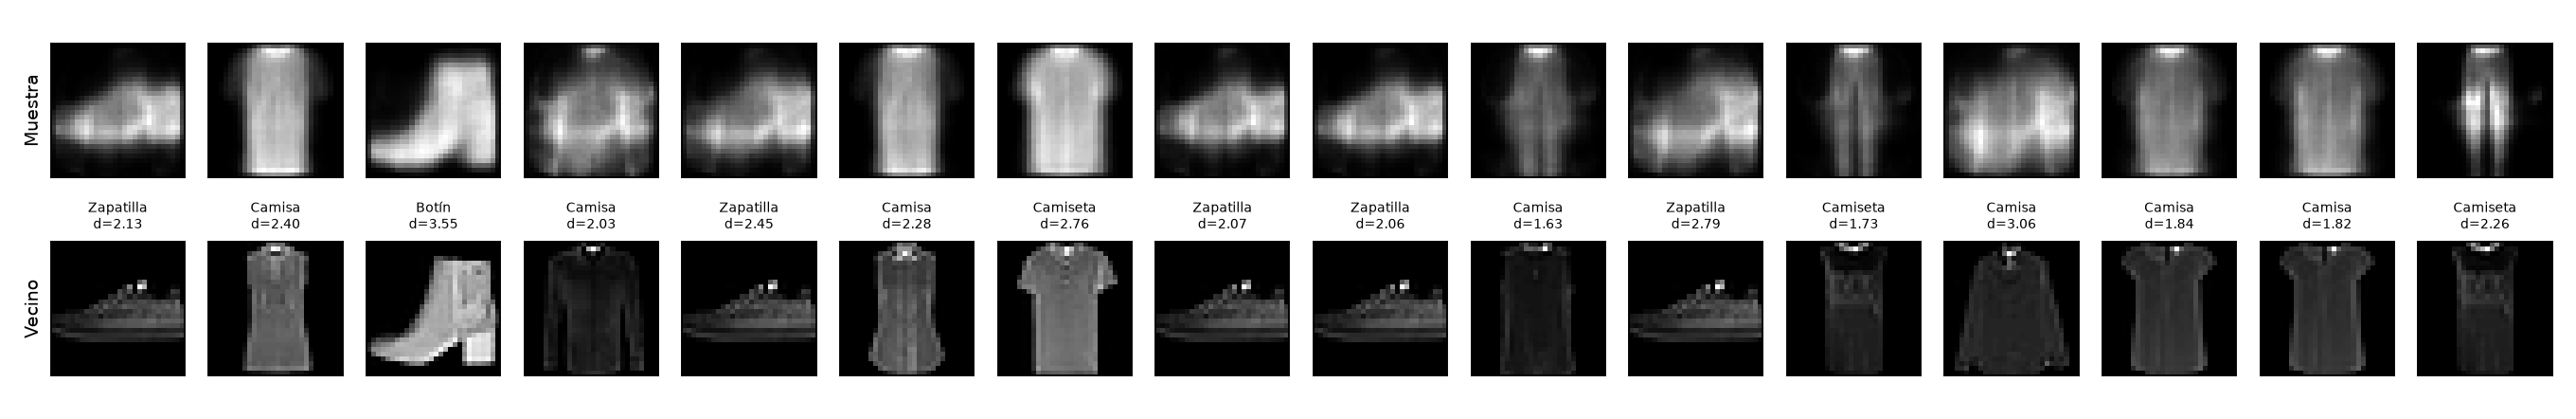

In [8]:
import statistics

generated, reference = metrics["nearest_neighbor_distances"], metrics["test_reference_distances"]
print(f"Muestras generadas → entrenamiento: mín {min(generated):.2f} | mediana {statistics.median(generated):.2f}")
print(f"Prueba real        → entrenamiento: mín {min(reference):.2f} | mediana {statistics.median(reference):.2f}")
print(f"Vecinos distintos para 16 muestras: {len(set(metrics['nearest_neighbor_train_indices']))}")
diversity = metrics["diversity"]
print(f"Distancia media entre pares · generadas {diversity['generated_mean_pairwise']:.2f} | reales {diversity['real_mean_pairwise']:.2f}"
      f" | razón {diversity['ratio']:.2f}")
display(Image(filename=str(REPORTS / "nearest_neighbors.png")))

**Lectura.**
- **Memoria:** la mediana de distancia de las muestras al entrenamiento (2.20) es **menor** que la de imágenes reales de prueba (3.72). No se interpreta como copia: las muestras del VAE son imágenes borrosas de bajo contraste, y la distancia euclidiana por píxeles favorece justamente ese tipo de imagen (un "promedio" está más cerca de muchos ejemplos que cualquier imagen nítida). Además, ninguna muestra está más cerca del entrenamiento que la imagen real más cercana (mín 1.63 frente a 1.39) y la inspección visual del panel no muestra duplicados. Se concluye que **no hay evidencia de memorización**, pero tampoco una garantía de privacidad.
- **Diversidad:** la distancia media entre pares de muestras generadas es apenas el **53 %** de la que hay entre imágenes reales, y las 16 muestras del panel solo tienen 10 vecinos distintos. Confirma cuantitativamente la diversidad limitada observada en el panel.

## 9. Costo computacional

In [9]:
size_kb = {path.name: round(path.stat().st_size / 1024) for path in sorted((ROOT / "models").glob("*.keras"))}
print(f"Tiempo AE: {metrics['ae_train_seconds']:.1f} s | Tiempo VAE: {metrics['vae_train_seconds']:.1f} s (CPU)")
print(f"Parámetros AE: {metrics['ae_parameters']:,} | encoder VAE: {metrics['encoder_parameters']:,} | decoder VAE: {metrics['decoder_parameters']:,}")
print("Tamaño en disco (KB):", size_kb)

Tiempo AE: 4.6 s | Tiempo VAE: 9.5 s (CPU)
Parámetros AE: 25,888 | encoder VAE: 100,996 | decoder VAE: 101,520
Tamaño en disco (KB): {'autoencoder.keras': 331, 'decoder.keras': 416}


## 10. Tabla principal de resultados (`reports/results_table.md`)

In [10]:
display(Markdown((REPORTS / "results_table.md").read_text(encoding="utf-8")))

| Métrica | AE | VAE |
|---|---|---|
| BCE/píxel · prueba | 0.3068 | 0.3411 |
| MSE/píxel · prueba | 0.0203 | 0.0332 |
| Mejor val_loss (BCE/píxel) | 0.3071 | — (sin validación) |
| KL final (entrenamiento) | — | 6.26 |
| Genera desde N(0, I) | No | Sí |
| Mediana dist. vecino (muestras / prueba real) | — | 2.20 / 3.72 |
| Razón de diversidad (generadas / reales) | — | 0.53 |
| Parámetros | 25,888 | 202,516 |
| Tiempo de entrenamiento CPU (s) | 4.6 | 9.5 |


## 11. Conclusión

La interpretación completa (reconstrucción, generación, diversidad, espacio latente, costo, riesgos y decisión de uso) está en el **Cierre interpretativo** del `README.md`, y la ficha técnica en `MODEL_CARD.md`. En síntesis: el AE reconstruye mejor pero no se usa para generar; el VAE permite muestrear un espacio continuo a costa de nitidez y diversidad. El modelo es apto como demostración académica y no como fuente de imágenes realistas ni de datos sintéticos privados.